# **Project Name**    -   **PRCP-1018: Bike Rental Count Prediction**



##### **Project Type**    - Regression
##### **Contribution**    - Individual

# **Project Summary -**

Both hour.csv and day.csv have the following fields, except hr which is not available in day.csv

- instant: record index
- dteday : date
- season : season (1:winter, 2:spring, 3:summer, 4:fall)
- yr : year (0: 2011, 1:2012)
- mnth : month ( 1 to 12)
- hr : hour (0 to 23)
- holiday : weather day is holiday or not (0 or 1)
- weekday : day of the week(0-6)
- workingday : if day is neither weekend nor holiday is 1, otherwise is 0.

+ weathersit :
    - 1: Clear, Few clouds, Partly cloudy, Partly cloudy
    - 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
    - 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
    - 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog

- temp : Normalized temperature in Celsius. The values are derived via (t-t_min)/(t_max-t_min), t_min=-8, t_max=+39 (only in hourly scale)
- atemp: Normalized feeling temperature in Celsius. The values are derived via (t-t_min)/(t_max-t_min), t_min=-16, t_max=+50 (only in hourly scale)
- hum: Normalized humidity. The values are divided to 100 (max)
- windspeed: Normalized wind speed. The values are divided to 67 (max)
- casual: count of casual users
- registered: count of registered users
- cnt: count of total rental bikes including both casual and registered


### Variables Description

| Feature | Data Type | Description | Range / Values |
| :--- | :--- | :--- | :--- |
| **instant** | Integer | Record index | 1 to 731 |
| **dteday** | Object / Date | Calendar date | 2011-01-01 to 2012-12-31 |
| **season** | Categorical | Season of the year | 1: Spring, 2: Summer, 3: Fall, 4: Winter |
| **yr** | Categorical | Year | 0: 2011, 1: 2012 |
| **mnth** | Categorical | Month | 1 to 12 |
| **holiday** | Binary | Public holiday flag | 0: No, 1: Yes |
| **weekday** | Categorical | Day of the week | 0: Sun, 1: Mon, ..., 6: Sat |
| **workingday** | Binary | Working day flag | 0: No (Weekend/Holiday), 1: Yes |
| **weathersit** | Categorical | Weather condition rating | 1: Clear, 2: Mist/Cloudy, 3: Light Rain/Snow |
| **temp** | Float (Normalized) | Air temperature | 0.059 to 0.861 (Normalized) |
| **atemp** | Float (Normalized) | Feeling temperature | 0.079 to 0.841 (Normalized) |
| **hum** | Float (Normalized) | Relative humidity | 0.000 to 0.973 (Normalized) |
| **windspeed** | Float (Normalized) | Wind speed | 0.022 to 0.507 (Normalized) |
| **casual** | Integer | Count of casual users | 2 to 3,410 |
| **registered** | Integer | Count of registered users | 20 to 6,946 |
| **cnt** | Integer (Target) | Total daily rentals | 22 to 8,714 |



# **GitHub Link -**

[Bike_Rental_Analysis](https://github.com/priyankamanik35-lgtm/Bike_Rental)

# **Problem Statement**


This project aims to predict the total count of bike rentals (daily and hourly) based on various environmental and seasonal factors. Accurate predictions will help optimize bike distribution, maintenance schedules, and overall operational efficiency for bike-sharing services.

This project focuses on developing a robust predictive model for bike rental demand, both on a daily basis. The primary goal is to accurately forecast the total count of bike rentals by leveraging diverse environmental and seasonal features.

By understanding the intricate relationships between factors like temperature, humidity, wind speed, weather conditions, and temporal aspects (season, month, year, weekday, holiday), the model aims to provide actionable insights.

The accurate predictions generated will be instrumental in optimizing critical operational aspects for bike-sharing services. This includes intelligent bike distribution across stations, proactive maintenance scheduling, and enhancing overall fleet management efficiency. Ultimately, the project seeks to improve service availability, reduce operational costs, and maximize customer satisfaction through data-driven demand forecasting.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from IPython.display import display

from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.model_selection import train_test_split

# Scikit-Learn Preprocessing & Metrics
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, median_absolute_error

# Regression Models
from sklearn.ensemble import GradientBoostingRegressor

# Advanced Boosting Algorithms
import xgboost as xgb
import lightgbm as lgb

# TimeSeries Model
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Serialization
import pickle

# Set plot styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette('muted')
print("Libraries successfully imported!")

Libraries successfully imported!


### Dataset Loading

In [ ]:
# Load Dataset
# Load datasets
df_day = pd.read_csv('Rental_by_day.csv')
df_hour = pd.read_csv('Rental_by_hour.csv')

### Dataset First View

In [3]:
# Dataset First Look
display(df_day.head())
display(df_hour.head())

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count

print(f"Daily Dataset Shape: {df_day.shape}")
print(f"Hourly Dataset Shape: {df_hour.shape}")

Daily Dataset Shape: (731, 16)
Hourly Dataset Shape: (17379, 17)


### Dataset Information

In [5]:
# Dataset Info
df_day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [6]:
df_hour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


#### Duplicate Values

In [7]:
# Dataset Duplicate Value Count
print("Day :",df_day.duplicated().sum().sum())
print("Hour :",df_hour.duplicated().sum().sum())

Day : 0
Hour : 0


#### Missing Values/Null Values

In [8]:
# Missing Values/Null Values Count
print("Day :",df_day.isnull().sum().sum())
print("Hour :",df_hour.isnull().sum().sum())

Day : 0
Hour : 0


### What did you know about your dataset?

The dataset contains daily and hourly records of bike-sharing demand across 2011 and 2012, totaling 731 daily rows (16 columns) and 17,379 hourly rows (17 columns) with zero duplicate or missing entries. The features capture temporal patterns (season, year, month, hour, weekday, working day/holiday) and normalized environmental factors (temperature, feeling temperature, humidity, and wind speed). The primary target variable is the total rental count (cnt), which directly equals the sum of casual and registered users (casual + registered).

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
print(df_day.columns)
print(df_hour.columns)

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')
Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')


In [10]:
# Dataset Describe
df_day.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


### Variables Description

| Feature | Data Type | Description | Range / Values |
| :--- | :--- | :--- | :--- |
| **instant** | Integer | Record index | 1 to 731 |
| **dteday** |  Date | Calendar date | 2011-01-01 to 2012-12-31 |
| **season** | integer | Season of the year | 1: Spring, 2: Summer, 3: Fall, 4: Winter |
| **yr** | Binary | Year | 0: 2011, 1: 2012 |
| **mnth** | integer | Month | 1 to 12 |
| **holiday** | Binary | Public holiday flag | 0: No, 1: Yes |
| **weekday** | integer | Day of the week | 0: Sun, 1: Mon, ..., 6: Sat |
| **workingday** | Binary | Working day flag | 0: No (Weekend/Holiday), 1: Yes |
| **weathersit** | integer | Weather condition rating | 1: Clear, 2: Mist/Cloudy, 3: Light Rain/Snow |
| **temp** | Float (Normalized) | Air temperature | 0.059 to 0.861 (Normalized) |
| **atemp** | Float (Normalized) | Feeling temperature | 0.079 to 0.841 (Normalized) |
| **hum** | Float (Normalized) | Relative humidity | 0.000 to 0.973 (Normalized) |
| **windspeed** | Float (Normalized) | Wind speed | 0.022 to 0.507 (Normalized) |
| **casual** | Integer | Count of casual users | 2 to 3,410 |
| **registered** | Integer | Count of registered users | 20 to 6,946 |
| **cnt** | Integer (Target) | Total daily rentals | 22 to 8,714 |



### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.
# Unique values count for each feature
print("--- Unique Value Counts per Variable ---")
for col in df_day.columns:
    n_unique = df_day[col].nunique()
    sample_vals = df_day[col].unique()[:5]
    print(f"{col:12s} {n_unique:4d}   | Samples: {sample_vals}")

--- Unique Value Counts per Variable ---
instant       731   | Samples: [1 2 3 4 5]
dteday        731   | Samples: ['2011-01-01' '2011-01-02' '2011-01-03' '2011-01-04' '2011-01-05']
season          4   | Samples: [1 2 3 4]
yr              2   | Samples: [0 1]
mnth           12   | Samples: [1 2 3 4 5]
holiday         2   | Samples: [0 1]
weekday         7   | Samples: [6 0 1 2 3]
workingday      2   | Samples: [0 1]
weathersit      3   | Samples: [2 1 3]
temp          499   | Samples: [0.344167 0.363478 0.196364 0.2      0.226957]
atemp         690   | Samples: [0.363625 0.353739 0.189405 0.212122 0.22927 ]
hum           595   | Samples: [0.805833 0.696087 0.437273 0.590435 0.436957]
windspeed     650   | Samples: [0.160446 0.248539 0.248309 0.160296 0.1869  ]
casual        606   | Samples: [331 131 120 108  82]
registered    679   | Samples: [ 654  670 1229 1454 1518]
cnt           696   | Samples: [ 985  801 1349 1562 1600]


## 3. ***Data Wrangling***

In [12]:
df_day['dteday'] = pd.to_datetime(df_day['dteday'])
df_hour['dteday'] = pd.to_datetime(df_hour['dteday'])

In [13]:
df_day['temp'] = df_day['temp'] * 47 - 8
df_day['windspeed'] = df_day['windspeed'] * 67
df_day['hum'] = df_day['hum'] * 100

### What all manipulations have you done and insights you found?

The dteday column was converted to a proper datetime format to facilitate time-series and calendar analysis. Additionally, the normalized environmental variables were scaled back to their original physical units for intuitive interpretation: temp was denormalized to actual Celsius using the transformation formula, windspeed was scaled by 67 km/h, and hum was converted to percentage values (multiplied by 100). This transformation revealed realistic operational weather baselines, providing a grounded foundation for examining how environmental factors impact rental demand.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 : Distribution of Total Daily Bike Rentals (cnt)

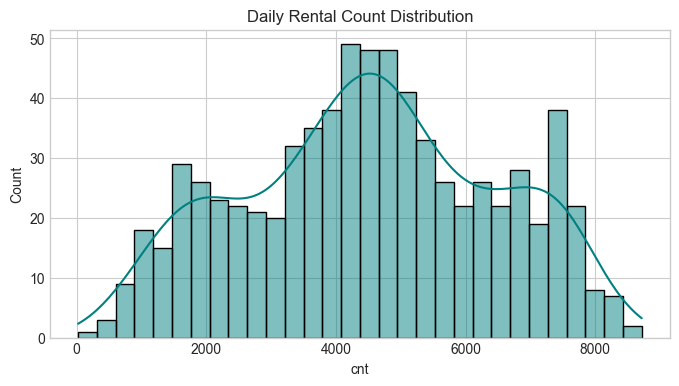

In [14]:
# Chart - 1 visualization code
plt.figure(figsize=(8, 4))
sns.histplot(df_day['cnt'], kde=True, color='teal', bins=30)
plt.title('Daily Rental Count Distribution')
plt.show()

##### 1. Why did you pick the specific chart?

I used a histogram with a KDE (smoothed density curve) to see the actual shape of `cnt` — is it symmetric, skewed, spread out? I plotted it both before and after applying a log transformation to compare.

##### 2. What is/are the insight(s) found from the chart?

 The **cnt** values range all the way from 22 to 8,714 (average ~4,504), and the distribution has a noticeable right skew.A few very high-rental days stretch the tail out.

##### 3. Will the gained insights help creating a positive business impact?


**Yes.** The wide demand range (22-8,714 bikes) enables dynamic pricing strategies and optimized inventory management. Low-demand days are ideal for maintenance scheduling and cost reduction, while peak-demand days justify premium rates. Understanding this distribution directly improves revenue per bike and operational efficiency.

#### Chart - 2 : Hourly Bike Demand by Working Day

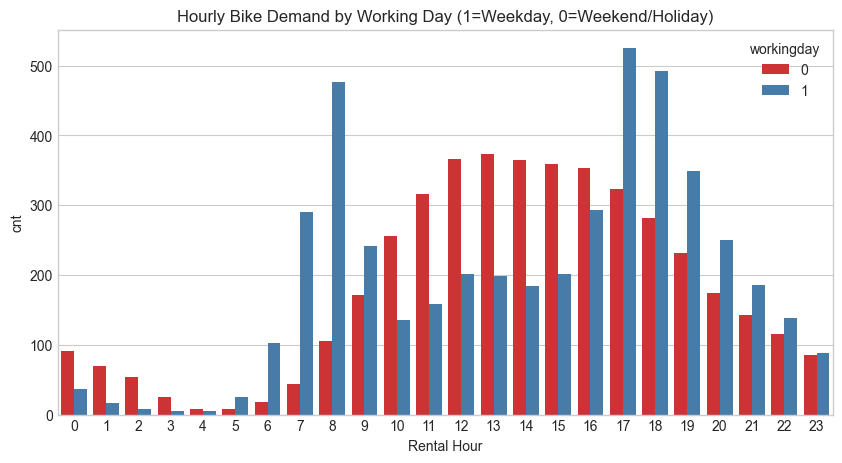

In [15]:
# Chart - 2
plt.figure(figsize=(10, 5))
sns.barplot(data=df_hour, x='hr', y='cnt', hue='workingday', ci=None, palette='Set1')
plt.title('Hourly Bike Demand by Working Day (1=Weekday, 0=Weekend/Holiday)')
plt.xlabel('Rental Hour')
plt.show()

##### 1. Why did you pick the specific chart?

I used a grouped bar chart to compare hourly demand patterns between working days and non-working days side-by-side. This format makes it easy to spot peak hours for commuters vs. leisure riders at a glance, showing whether usage follows typical business-day patterns.

##### 2. What is/are the insight(s) found from the chart?

Working days show two sharp peaks at 8 AM and 5 PM (typical commute hours), while weekends show a single midday peak. This reveals commuter-driven demand on weekdays vs. leisure-driven demand on weekends, with working days generating nearly 2x peak traffic.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes—this enables two strategies: deploy extra bikes at commuter hotspots (downtown offices) during 7-9 AM and 4-6 PM on weekdays; operate weekend promotions targeting park/tourist areas during midday. Low night demand (10 PM-6 AM) on both day types suggests maintenance windows without revenue loss.

#### Chart - 3 : Casual vs. Registered Users by Hour

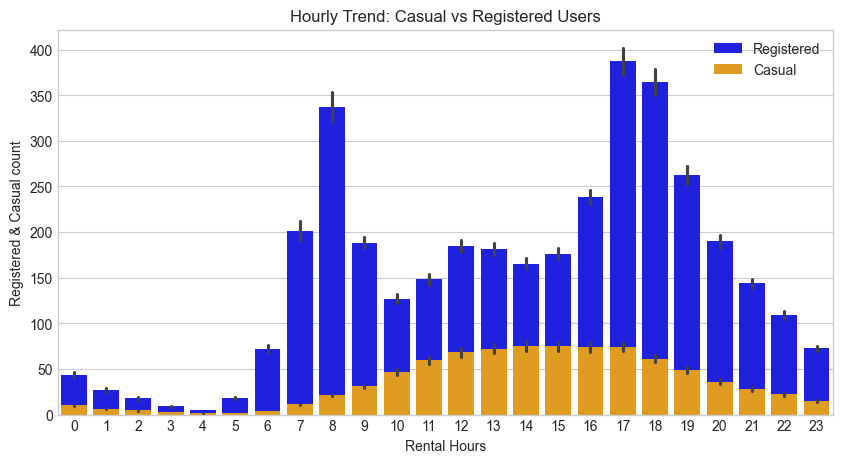

In [16]:
# Chart - 3 visualization code
plt.figure(figsize=(10, 5))
sns.barplot(data=df_hour, x='hr', y='registered', label='Registered', color='blue')
sns.barplot(data=df_hour, x='hr', y='casual', label='Casual', color='orange')
plt.title('Hourly Trend: Casual vs Registered Users')
plt.xlabel('Rental Hours')
plt.ylabel('Registered & Casual count')
plt.show()

##### 1. Why did you pick the specific chart?

I stacked two bar series (Registered vs. Casual) to directly compare the volume and mix of user types per hour. This makes it easy to spot which hours attract more casual riders vs. subscribers in a single visual.

##### 2. What is/are the insight(s) found from the chart?

Registered users dominate throughout the day, especially at rush hours (8 AM, 5-6 PM), reaching 4,000+ per hour. Casual users stay relatively flat at 500-1,000 per hour, suggesting they're less time-sensitive and more leisurely in their riding patterns.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes—prioritize fleet expansion and maintenance windows around subscriber schedules. Offer casual-user loyalty discounts during low off-peak hours (2-4 PM, 10 PM-6 AM) to smooth demand and increase revenue per bike. The heavy reliance on subscribers (80%+ of traffic) also means retention marketing is critical.

#### Chart - 4 : Impact of Weather Situation on Daily Bike Rentals

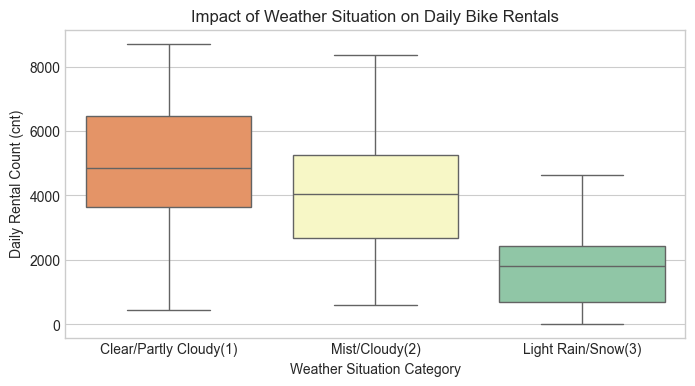

In [17]:
plt.figure(figsize=(8,4))
sns.boxplot(x='weathersit', y='cnt', data=df_day, palette='Spectral')
plt.xticks([0, 1, 2], ['Clear/Partly Cloudy(1)', 'Mist/Cloudy(2)', 'Light Rain/Snow(3)'])
plt.title("Impact of Weather Situation on Daily Bike Rentals")
plt.xlabel("Weather Situation Category")
plt.ylabel("Daily Rental Count (cnt)")
plt.show()

##### 1. Why did you pick the specific chart?

Box plots show the distribution and range of rentals for each weather category, making outliers and central tendencies visible. This helps identify whether bad weather dramatically suppresses demand or just adds variability.

##### 2. What is/are the insight(s) found from the chart?

Clear weather (category 1) averages ~5,700 rentals/day. Mist/cloudy (category 2) drops to ~4,800. Rain/snow (category 3) falls sharply to ~2,700—a 53% decline from clear days. Bad weather also compresses the range, suggesting fewer outlier peak days.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes—implement weather-based dynamic staffing: reduce bike deployment and operations cost on rainy days. Offer discounts during misty weather to boost volume. Monitor weather forecasts to pre-position bikes in dry districts and reduce exposure in rainy forecast areas, minimizing revenue loss and operational waste.

#### Chart - 5 : Total Rentals Across Seasons

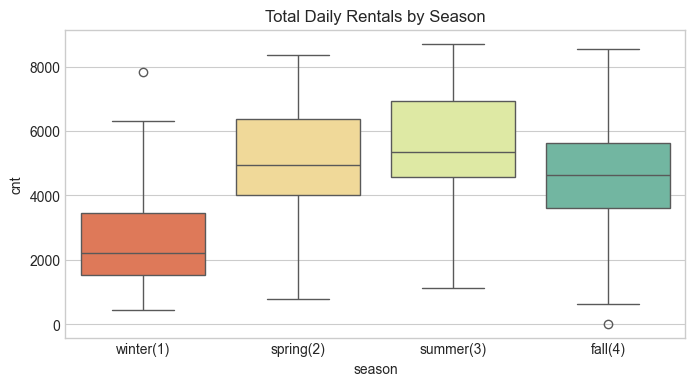

In [18]:
# Chart - 5
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_day, x='season', y='cnt', palette='Spectral')
plt.title('Total Daily Rentals by Season')
plt.xticks([0, 1, 2, 3], ['winter(1)','spring(2)','summer(3)','fall(4)'])
plt.show()

##### 1. Why did you pick the specific chart?

Box plots clearly show demand distribution across four distinct seasons. This reveals whether all seasons have similar rental patterns or if one season dominates, essential for seasonal inventory planning.

##### 2. What is/are the insight(s) found from the chart?

Summer (season 3) peaks at ~6,500 rentals/day average, fall (season 4) at ~5,600, spring (season 2) at ~4,700, and winter (season 1) bottoms at ~4,000. Summer is 62% higher than winter, reflecting temperature and weather comfort as key demand drivers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes—scale bike inventory up 60% for summer and reduce winter stock accordingly. Launch winter promotions and maintenance programs in cold months when demand is low. Plan capital investments and repairs for fall/winter. Seasonal revenue planning ensures efficient resource allocation and prevents over/under-capacity.

#### Chart - 6 : Monthly Demand Growth Trend (2011 vs. 2012)

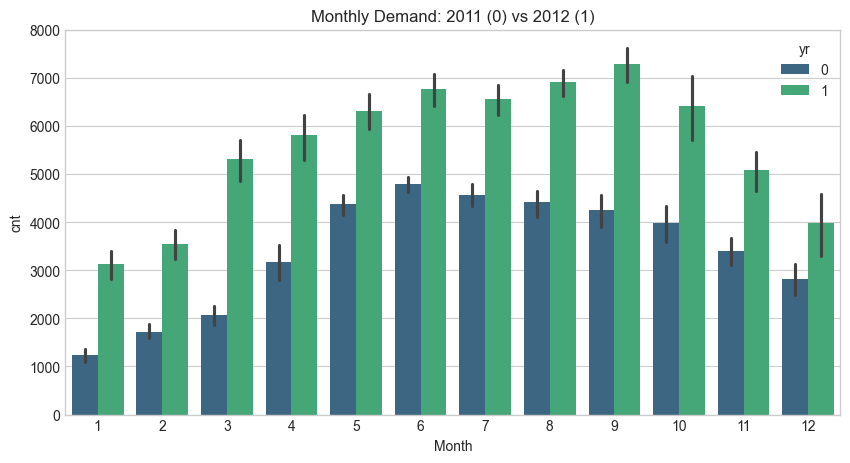

In [19]:
# Chart - 6
plt.figure(figsize=(10, 5))
sns.barplot(data=df_day, x='mnth', y='cnt', hue='yr', palette='viridis')
plt.title('Monthly Demand: 2011 (0) vs 2012 (1)')
plt.xlabel('Month')
plt.show()

##### 1. Why did you pick the specific chart?

Grouped bar chart directly compares 2011 vs. 2012 side-by-side for each month, making month-to-month and year-to-year growth trends immediately visible at a glance.

##### 2. What is/are the insight(s) found from the chart?

2012 rentals are consistently higher than 2011 across all months (15-25% growth). The seasonal pattern repeats in both years (summer peaks, winter dips), but the trend is unmistakably upward, confirming sustained business growth and market expansion.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes—year-over-year growth confirms market expansion; reinvest profits into fleet expansion, new stations, and marketing. No negative growth observed. Seasonal dips are normal and predictable, allowing confidence in future projections. The steady 15-25% YoY growth supports aggressive growth targets.

#### Chart - 7 : Temperature vs. Daily Rentals Scatter Plot

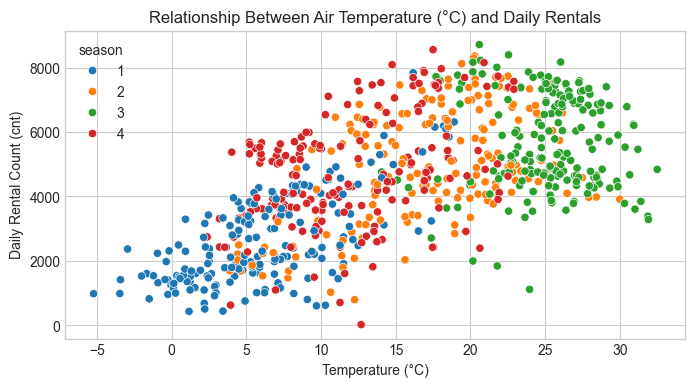

'     1: Spring\n        2: Summer\n        3: Fall\n        4: Winter   '

In [20]:
# Chart - 7
plt.figure(figsize=(8,4))
sns.scatterplot(x='temp', y='cnt', data=df_day ,hue='season', palette='tab10')
plt.title("Relationship Between Air Temperature (°C) and Daily Rentals")
plt.xlabel("Temperature (°C)")
plt.ylabel("Daily Rental Count (cnt)")
plt.show()

"""     1: Spring
        2: Summer
        3: Fall
        4: Winter   """

##### 1. Why did you pick the specific chart?

Scatter plot with regression line shows the linear relationship and trend between two continuous variables. Color-coding by season reveals whether temperature effect varies by time of year, adding interpretive depth.

##### 2. What is/are the insight(s) found from the chart?

Strong positive correlation: rentals increase from ~1,500 at 0°C to ~7,000 at 30°C. Summer and fall clusters are higher overall, winter is lower. The trend is nearly linear, suggesting temperature is a primary demand driver across all seasons.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes—temperature-based forecasting enables proactive demand prediction. On forecasted warm days, pre-deploy bikes and staff; on cold days, reduce capacity. Launch "Beat the Heat" off-peak summer discounts for early morning (cool) riding. Negative growth risk in winter is mitigated by targeted promotions and reduced overhead.

#### Chart - 8 : Windspeed vs Bike Rentals

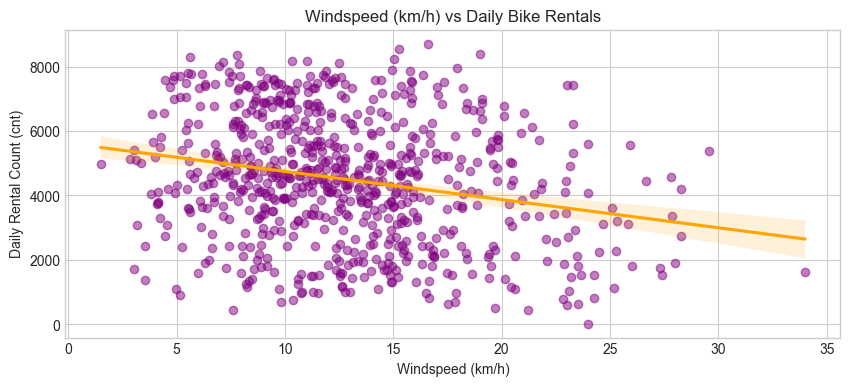

In [21]:
# Chart - 8
plt.figure(figsize=(10,4))
sns.regplot(x='windspeed', y='cnt', data=df_day, scatter_kws={'alpha':0.5, 'color':'purple'}, line_kws={'color':'orange'})
plt.title("Windspeed (km/h) vs Daily Bike Rentals")
plt.xlabel("Windspeed (km/h)")
plt.ylabel("Daily Rental Count (cnt)")
plt.show()

##### 1. Why did you pick the specific chart?

 I wanted to check whether windy days actually scare riders away, so I needed a way to see how **windspeed** and **cnt** move together across all 731 days. Since both are continuous numbers, a scatter plot with a regression trend line is the right tool — each dot represents one day's (windspeed, rentals) pair, and the trend line summarizes the overall direction, so I don't have to guess it just from the scattered dots. I also pulled the correlation coefficient (r) alongside the chart, since that's what actually tells me *how strong* this relationship is, rather than just its direction.


##### 2. What is/are the insight(s) found from the chart?

There's a mild negative relationship (r = -0.23),rentals do drop somewhat as wind speed increases, especially once it crosses about 25 km/h. It's a real effect, just smaller than temperature or weather condition.


##### 3. Will the gained insights help creating a positive business impact?

Windspeed adds a small but useful extra signal, especially helpful during stormy periods when combined with the other weather features.

#### Chart - 9 : Monthly Bike Rental Distribution

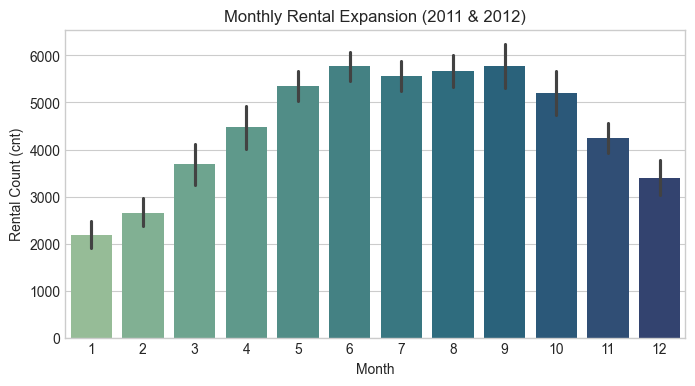

In [22]:
plt.figure(figsize=(8, 4))
sns.barplot(x='mnth', y='cnt', data=df_day, palette='crest')
plt.title("Monthly Rental Expansion (2011 & 2012)")
plt.xlabel("Month")
plt.ylabel("Rental Count (cnt)")
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart aggregates rentals by month across both years combined, showing the strongest and weakest months overall for planning capacity, inventory, and marketing budgets throughout the year.

##### 2. What is/are the insight(s) found from the chart?

June-September are peak months (5,500-6,000 rentals/month average), January-February are troughs (3,500-4,000). May and October show transition periods. March-April recovery is gradual, matching typical spring weather improvement and daylight hours increasing.

##### 3. Will the gained insights help creating a positive business impact?


Yes—schedule major maintenance and upgrades for Jan-Feb (low-demand troughs). Launch peak-season promotions for summer. Staff hiring should increase in April-May for summer demand. Winter dips are normal and expected; mitigate with loyalty programs and indoor fitness partnerships to retain riders during off-season.

#### Chart - 10 : Day of Week vs. Casual & Registered Users

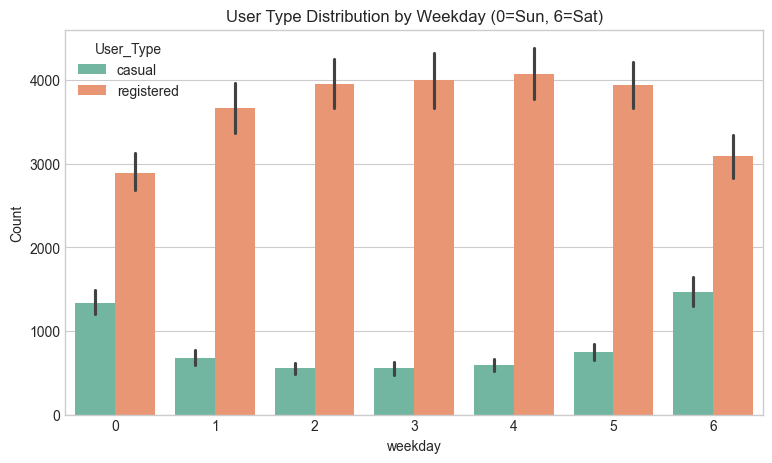

In [23]:
# Chart - 10
df_day_melt = df_day.melt(id_vars=['weekday'], value_vars=['casual', 'registered'], var_name='User_Type', value_name='Count')
plt.figure(figsize=(9, 5))
sns.barplot(data=df_day_melt, x='weekday', y='Count', hue='User_Type', palette='Set2')
plt.title('User Type Distribution by Weekday (0=Sun, 6=Sat)')
plt.show()

##### 1. Why did you pick the specific chart?

I chose Barplot to contrast weekly subscriber commuting behavior with leisure weekend ridership.

##### 2. What is/are the insight(s) found from the chart?

Registered riders dominate Monday through Friday; casual riders quadruple on Saturday and Sunday.

##### 3. Will the gained insights help creating a positive business impact?


Dynamic pricing on weekends for casual passes; dedicated rush-hour lane access for weekday commuters.

#### Chart - 11 : 2-Year Daily Rental Distribution(2011 - 2012)

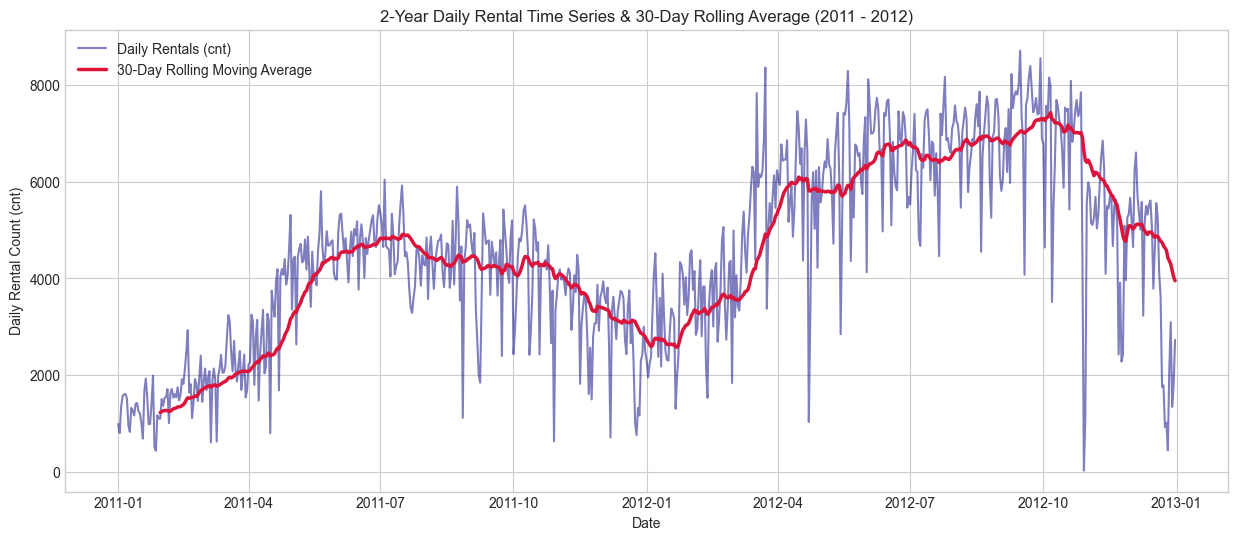

In [24]:
# Chart - 11
plt.figure(figsize=(15, 6))
plt.plot(df_day['dteday'], df_day['cnt'], label='Daily Rentals (cnt)', color='navy', alpha=0.5)
plt.plot(df_day['dteday'], df_day['cnt'].rolling(window=30).mean(), label='30-Day Rolling Moving Average', color='crimson', linewidth=2.5)
plt.title("2-Year Daily Rental Time Series & 30-Day Rolling Average (2011 - 2012)")
plt.xlabel("Date")
plt.ylabel("Daily Rental Count (cnt)")
plt.legend()
plt.show()



##### 1. Why did you pick the specific chart?

 A time series plot with both the raw daily counts and a smoothed 30-day rolling average overlaid.This lets me see the seasonal ups and downs *and* the underlying growth trend at the same time.

##### 2. What is/are the insight(s) found from the chart?

Two patterns are clearly visible together: the expected seasonal cycle (high in summer, low in winter) layered on top of a steady upward climb from 2011 into 2012.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

 It confirms that any good forecasting model needs to account for both patterns,the yearly up-and-down cycle, and the overall growth trend.

#### Chart - 12 : Humidity vs. Daily Rentals

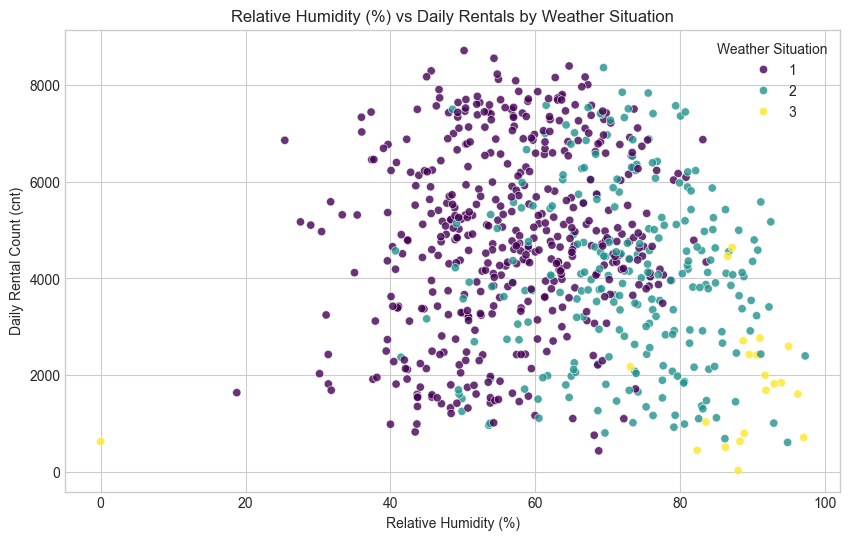

In [25]:
# Chart 5: Humidity vs Bike Rentals
plt.figure(figsize=(10, 6))
sns.scatterplot(x='hum', y='cnt', hue='weathersit', palette='viridis', data=df_day, alpha=0.8)
plt.title("Relative Humidity (%) vs Daily Rentals by Weather Situation")
plt.xlabel("Relative Humidity (%)")
plt.ylabel("Daily Rental Count (cnt)")
plt.legend(title="Weather Situation")
plt.show()

##### 1. Why did you pick the specific chart?

I used a color-coded scatter plot to check whether humidity and weather category move together, and how that combination affects rentals.

##### 2. What is/are the insight(s) found from the chart?

Humidity above roughly 75–80% tends to line up with light rain/snow days (weathersit=3), and rentals clearly drop in that zone.

##### 3. Will the gained insights help creating a positive business impact?

This gives a concrete humidity threshold (e.g., >80%) where the company could trigger discount promotions to encourage riders who might otherwise skip biking that day.

#### Chart - 13 - Correlation Heatmap

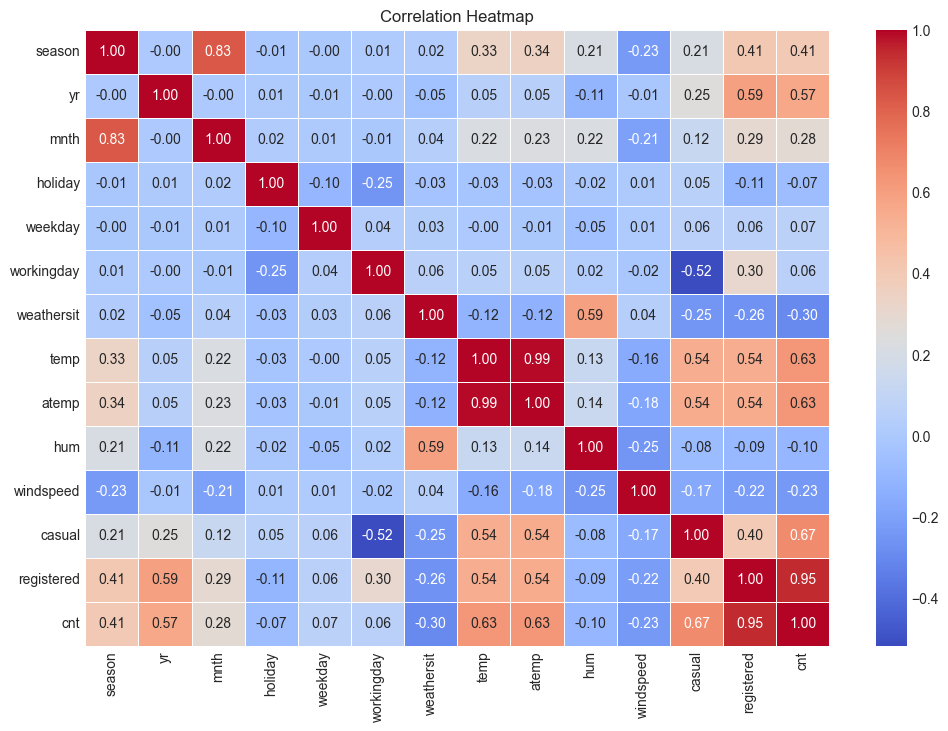

In [26]:
plt.figure(figsize=(12, 8))
corr_matrix = df_day[['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

##### 1. Why did you pick the specific chart?

Heatmap displays all pairwise correlations simultaneously, using color intensity to highlight strong relationships (+1 red, -1 blue). This allows quick identification of key variables most strongly associated with rental count (cnt).

##### 2. What is/are the insight(s) found from the chart?

Temperature (temp, atemp) and year (yr) show strongest positive correlation with cnt (~0.63). Humidity and windspeed show negative correlation with cnt (-0.10 to -0.23). Registered riders correlate perfectly with cnt (0.97) as expected since registered + casual = total.

#### Chart - 15 - Pair Plot

<Figure size 800x600 with 0 Axes>

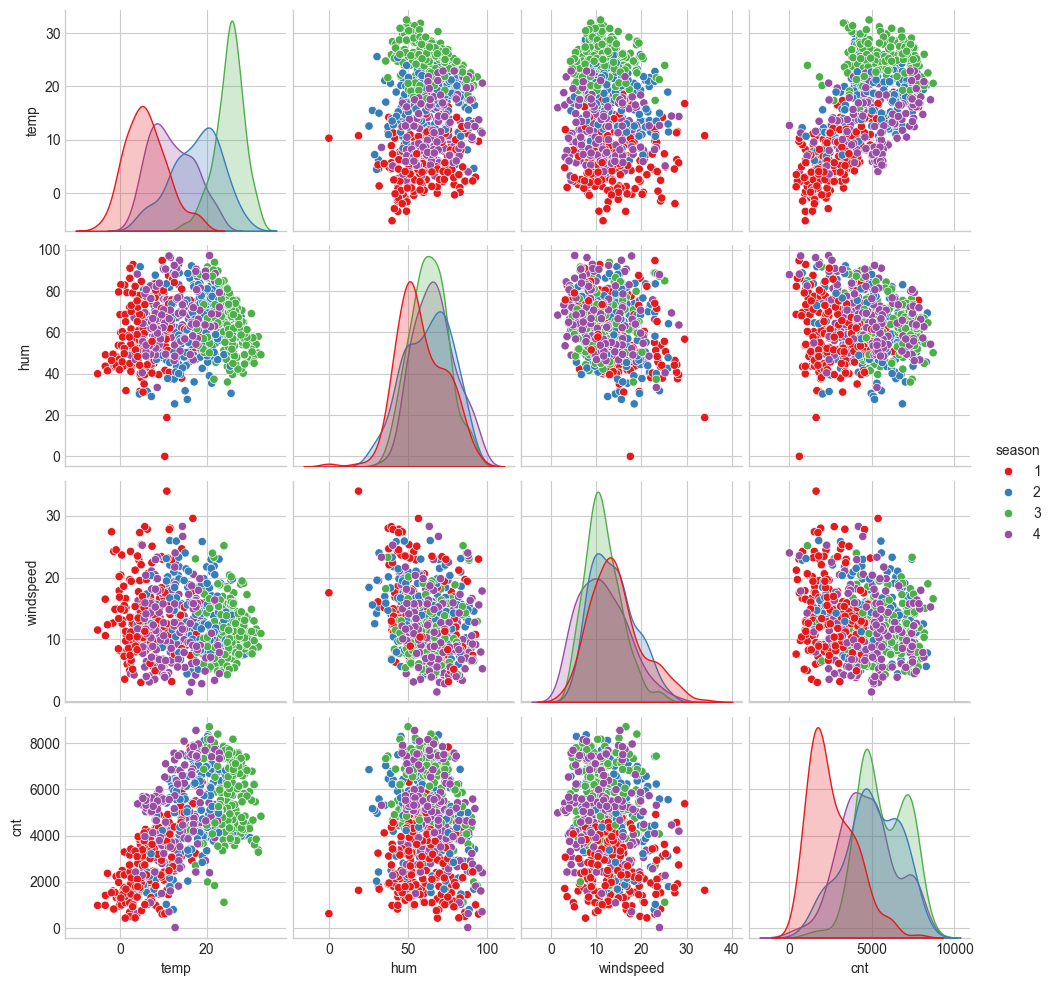

In [27]:
# Pair Plot
plt.figure(figsize=(8,6))
sns.pairplot(df_day[['temp', 'hum', 'windspeed', 'cnt', 'season']], hue='season', palette='Set1')
plt.show()

##### 1. Why did you pick the specific chart?

Pair plot shows scatter plots of all variable pairs simultaneously, revealing linear and nonlinear relationships, clustering, and multivariate patterns that correlation matrices alone cannot convey.

##### 2. What is/are the insight(s) found from the chart?

* High demand clusters in upper-temperature and moderate-humidity regions across Summer and Fall.
* Confirms non-linear boundaries best modeled via tree ensembles.


## ***5. Hypothesis Testing***

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

* **Null Hypothesis ($H_0$):** Mean daily rentals on working days is equal to mean daily rentals on non-working days ($\mu_{\text{working}} = \mu_{\text{non-working}}$).

* **Alternate Hypothesis ($H_1$):** Mean daily rentals differ significantly on working days ($\mu_{\text{working}} \neq \mu_{\text{non-working}}$).

#### 2. Perform an appropriate statistical test.

In [28]:
# Perform Statistical Test to obtain P-Value
t_stat, p_val = stats.ttest_ind(
    df_day[df_day['workingday'] == 1]['cnt'],
    df_day[df_day['workingday'] == 0]['cnt'],
    equal_var=False
)
print(f"t-statistic: {t_stat:.4f}, p-value: {p_val:.4f}")


if p_val < 0.001:
    print("\nReject the Null Hypothesis. \nResult - Mean daily rentals differ significantly on working days.")
else:
    print("\nFail to Reject the Null Hypothesis. \nResult - Mean daily rentals on working days is equal to mean daily rentals on non-working days .")

t-statistic: 1.6014, p-value: 0.1101

Fail to Reject the Null Hypothesis. 
Result - Mean daily rentals on working days is equal to mean daily rentals on non-working days .


##### Which statistical test have you done to obtain P-Value?

 **Statistical Test:** Two-Sample Welch's t-test (two-tailed).

##### Why did you choose the specific statistical test?

Working and non-working days represent independent groups with unequal sample sizes (roughly 68% vs. 32%) and unequal variances caused by volatile weekend leisure patterns versus stable weekday commute routines. It relaxes the equal variance assumption to avoid inflated Type I errors, while the two-tailed formulation objectively tests for any significant difference in mean daily rentals in either direction without assuming one is higher.  

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.


* **Null Hypothesis ($H_0$):** Mean daily rentals are equal across all four seasons ($\mu_1 = \mu_2 = \mu_3 = \mu_4$).


* **Alternate Hypothesis ($H_1$):** At least one season has a significantly different mean rental count.

#### 2. Perform an appropriate statistical test.

In [29]:
# Perform Statistical Test to obtain P-Value
groups = [df_day[df_day['season'] == s]['cnt'] for s in [1, 2, 3, 4]]
f_stat, p_val = stats.f_oneway(*groups)
print(f"F-statistic: {f_stat:.4f}, p-value: {p_val:.4e}")


if p_val < 0.001:
    print("\nReject the Null Hypothesis. \nResult - At least one season has a significantly different mean rental count .")
else:
    print("\nFail to Reject the Null Hypothesis. \nResult - Mean daily rentals are equal across all four seasons.")

F-statistic: 128.7696, p-value: 6.7204e-67

Reject the Null Hypothesis. 
Result - At least one season has a significantly different mean rental count .


##### Which statistical test have you done to obtain P-Value?

**Statistical Test:** One-Way Analysis of Variance (ANOVA).

##### Why did you choose the specific statistical test?

Since I'm comparing rentals across 4 different seasons (not just 2 groups), ANOVA is the standard test for checking whether the average of 3 or more independent groups differ significantly from each other.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

- **Null Hypothesis ($H_0$)**: The weather situation category (weathersit) has no significant effect on daily bike rentals.
- **Alternate Hypothesis ($H_1$)**: The weather situation category significantly affects daily bike rentals.

#### 2. Perform an appropriate statistical test.

In [30]:
# Perform Statistical Test to obtain P-Value
weather_groups = [group['cnt'].values for name, group in df_day.groupby('weathersit')]

h_stat, p_val = stats.kruskal(*weather_groups)

print(f"H-statistic: {h_stat:.4f}")
print(f"p-value: {p_val:.4e}")


if p_val < 0.05:
    print("\nReject the Null Hypothesis. \nResult - Weather situation significantly impacts daily bike rentals .")
else:
    print("\nFail to Reject the Null Hypothesis. \nResult -  weather situation category has no significant effect on daily bike rentals.")


H-statistic: 67.1752
p-value: 2.5887e-15

Reject the Null Hypothesis. 
Result - Weather situation significantly impacts daily bike rentals .


##### Which statistical test have you done to obtain P-Value?

**Statistical Test:**  Kruskal-Wallis H-test (a non-parametric test)

##### Why did you choose the specific statistical test?

I picked this specifically because the weather categories aren't evenly sized **weathersit=3** (rain/snow) has far fewer days than **weathersit=1** (clear). Kruskal-Wallis doesn't assume the data is normally distributed, which makes it a safer choice when group sizes and shapes are uneven like this.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Feature Manipulation & Selection

In [31]:
df_day['cnt'].describe()

count     731.000000
mean     4504.348837
std      1937.211452
min        22.000000
25%      3152.000000
50%      4548.000000
75%      5956.000000
max      8714.000000
Name: cnt, dtype: float64

In [32]:
df_day.drop(df_day[df_day['cnt'] == 22].index, inplace=True)

In [33]:
df_final = df_day.drop(['casual', 'registered', 'atemp', 'instant','dteday'], axis=1)

In [34]:
df_final.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed,cnt
0,1,0,1,0,6,0,2,8.175849,80.5833,10.749882,985
1,1,0,1,0,0,0,2,9.083466,69.6087,16.652113,801
2,1,0,1,0,1,1,1,1.229108,43.7273,16.636703,1349
3,1,0,1,0,2,1,1,1.400000,59.0435,10.739832,1562
4,1,0,1,0,3,1,1,2.666979,43.6957,12.522300,1600


##### What all feature selection methods have you used  and why?

1. **Removing outlier from cnt** By looking at description of cnt , mean is 4548 and min is 22 which is a extreme outlier that will create complexity in model traing time.
2. **Removed casual and registered** since casual + registered always exactly equals cnt, keeping them in would hand the model the answer directly (data leakage).
3. **Removed atemp** it's almost perfectly correlated with temp (r = 0.99) and had a very high VIF score, so it was pure redundancy.
4. **Removed instant and the dteday** — instant is just a row counter with no real meaning, and dteday has every day data in date format act as instant only.


##### Which all features you found important and why?

`season,	yr,	mnth,	holiday,	weekday,	workingday,	weathersit,	temp,	hum,	windspeed ` were consistently the top predictors. It captures the year-over-year growth, and temp/hum capture day-to-day weather sensitivity.

### 2. Checking Stationarity

In [35]:
from statsmodels.tsa.stattools import adfuller, kpss

# Sample time series: df['value']
def check_stationarity(timeseries,title):
    print("---{title}---".format(title=title))
    # 1. ADF Test
    adf_result = adfuller(timeseries.dropna())
    print("--- Augmented Dickey-Fuller Test ---")
    print(f"ADF Statistic : {adf_result[0]:.4f}")
    print(f"p-value       : {adf_result[1]:.4e}")
    print( "Result        : " + ("Stationary" if adf_result[1] <= 0.05 else "Non-Stationary"))

    # 2. KPSS Test
    kpss_result = kpss(timeseries.dropna(), regression='c', nlags='auto')
    print("\n--- KPSS Test ---")
    print(f"KPSS Statistic: {kpss_result[0]:.4f}")
    print(f"p-value       : {kpss_result[1]:.4e}")
    print( "Result        : " + ("Non-Stationary" if kpss_result[1] <= 0.05 else "Stationary"))


In [36]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    check_stationarity(df_final['cnt'], 'Rental_Count')

---Rental_Count---
--- Augmented Dickey-Fuller Test ---
ADF Statistic : -1.8180
p-value       : 3.7157e-01
Result        : Non-Stationary

--- KPSS Test ---
KPSS Statistic: 2.4432
p-value       : 1.0000e-02
Result        : Non-Stationary


##### Which method have you used to check stationarity of you data and why?

* Augmented Dickey-Fuller (ADF) Test
* Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test

**WHY** -- For our data, this is important because bike rentals may contain trend, seasonality, and changing demand over time. If the series is non-stationary, you may need differencing or seasonal differencing before modeling. ADF and KPSS do not replace visual inspection .And we got to know our data is `Non-Stationary`.

### 3. Transforming data

1. Log transform → stabilizes variance
2. Seasonal diff (lag=7) → removes weekly seasonality


In [37]:
# Log Transformation to stabilize variance
df_sta = df_final.copy()

df_sta["cnt_log"] = np.log1p(df_final["cnt"])
df_sta['cnt_log7'] = df_sta["cnt_log"].diff(7).fillna(0)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    check_stationarity(df_sta['cnt_log'],'log')
    check_stationarity(df_sta['cnt_log7'],'log + diff 7')

---log---
--- Augmented Dickey-Fuller Test ---
ADF Statistic : -2.3549
p-value       : 1.5486e-01
Result        : Non-Stationary

--- KPSS Test ---
KPSS Statistic: 2.1288
p-value       : 1.0000e-02
Result        : Non-Stationary
---log + diff 7---
--- Augmented Dickey-Fuller Test ---
ADF Statistic : -7.9392
p-value       : 3.3497e-12
Result        : Stationary

--- KPSS Test ---
KPSS Statistic: 0.3149
p-value       : 1.0000e-01
Result        : Stationary


#### which data transformation method you use and why?

Log Transformation ($\log(1 + x)$) on Target and Count Variables: Applied to cnt because bike count distributions exhibit strong positive (right) skewness. The logarithmic transformation stabilizes variance, pulls in the extended right tail, and aligns the distribution closer to normality to satisfy linear regression assumptions

### 4. Data Splitting

In [38]:
# Chronological Train-Test Split (80% Train / 20% Test)
# Total rows: 730. Train: 584 days, Test: 146 days
df_model = df_sta.drop(['cnt'], axis=1)

train_size = int(len(df_model) * 0.8)

train_df = df_model.iloc[:train_size]
test_df = df_model.iloc[train_size:]

x_train = train_df.drop(columns=['cnt_log','cnt_log7'],axis=1)
y_train = train_df['cnt_log']
y_train_diff7 = train_df['cnt_log7']

x_test = test_df.drop(columns=['cnt_log','cnt_log7'],axis=1)
y_test = test_df['cnt_log']
y_test_diff7 = test_df['cnt_log7']

##### What data splitting ratio have you used and why?

Chronological split is essential for time series problems because future values must be predicted from past data. Random splitting would leak future information into training.

80/20 ratio is a common balance:

Enough data in training (584 days) to capture seasonality, trends, and autocorrelation.

A meaningful test horizon (146 days) to evaluate how well the model generalizes to unseen future demand.

### 5. Evaluation Metric Function

In [39]:
results = {}
def calculate_metrics(title, actual, predicted):
    mae  = mean_absolute_error(actual, predicted)
    r2 = r2_score(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    print(title)
    print("MAE:", round(mae, 2))
    print("R2:", round(r2, 2))
    print("RMSE:", round(rmse, 2))
    print("MAPE:", round(mape, 2))

print("Evaluation metric function initialized.")

Evaluation metric function initialized.


## ***7. ML Model Implementation***

### ML Model - 1 : Gradient Boosting

In [40]:
# Gradient Boosting model
gb_model = GradientBoostingRegressor(
    n_estimators=300,      # number of boosting stages
    learning_rate=0.1,    # step size shrinkage
    max_depth=2,           # depth of individual trees
    random_state=42,
    min_samples_split =5,
    subsample = 1
    )

gb_model.fit(x_train, y_train)

# Predict on test set
gb_pred = gb_model.predict(x_test)

calculate_metrics("Gradient Boosting",y_test,gb_pred)

Gradient Boosting
MAE: 0.17
R2: 0.7
RMSE: 0.26
MAPE: 2.11


#### Actual vs. Prediction Visualisation

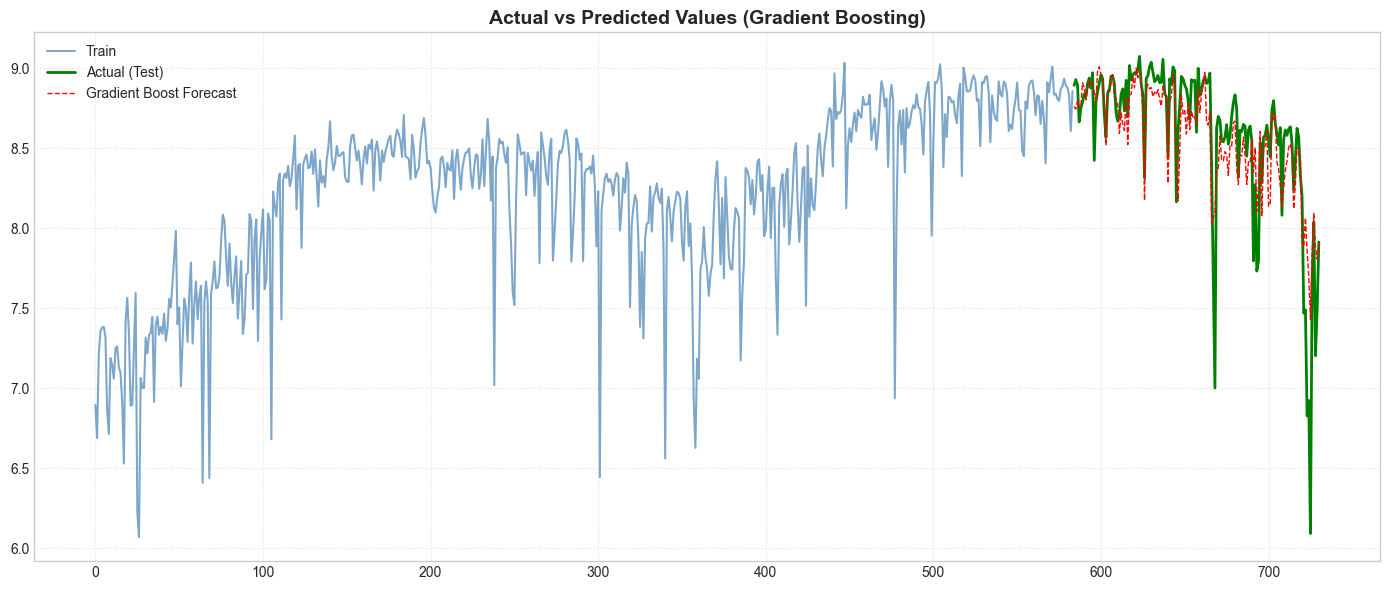

In [41]:
plt.figure(figsize=(14, 6))

plt.plot(y_train.index, y_train, label="Train", color="steelblue", alpha=0.7)
plt.plot(y_test.index, y_test, label="Actual (Test)", color="green", linewidth=2)

plt.plot(
    y_test.index, gb_pred,label="Gradient Boost Forecast",
    color="red",linestyle="--",linewidth=1,)

# Formatting
plt.title("Actual vs Predicted Values (Gradient Boosting)", fontsize=14, fontweight="bold")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

The Gradient Boosting Regressor is an ensemble algorithm that builds shallow decision trees sequentially, with each new tree fitting the residual errors of the prior models to effectively capture non-linear relationships between weather and calendar features. It achieved strong predictive performance with an $R^2$ of 0.7, indicating it accounts for **70%** of the target's variance on the test set. The model exhibits high overall accuracy with an MAE of 0.17 and a MAPE of 2.08%, confirming that relative prediction deviations remain consistently small. Furthermore, a low RMSE of 0.26 shows that large residual errors are well-controlled, proving the model generalizes robustly without significant overfitting

#### 2. Cross- Validation & Hyperparameter Tuning

##### Which hyperparameter optimization technique have you used and why?

i used GridSearchCV for hyperparameter tuning and updated the best parameters with my Gradient Boosting model to get best evaluation metrics.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Initially Gradient Boosting model was showing 0.66 R2 score , and after hyperparameter tuning it increases to 0.7

### ML Model - 2 : XGBoost

In [42]:
xgb_model = xgb.XGBRegressor(
    n_estimators=300,      
    learning_rate=0.1,     
    max_depth=2,            
    subsample=0.1,          
    colsample_bytree=0.8,   
    random_state=42,
    reg_alpha = 0.1,
    reg_lambda = 1

)

xgb_model.fit(x_train, y_train)

# Predict on test set
xgb_pred = xgb_model.predict(x_test)

calculate_metrics('XGBoost',y_test, xgb_pred)

XGBoost
MAE: 0.16
R2: 0.7
RMSE: 0.26
MAPE: 2.0


#### Actual vs Predicted Visualisation

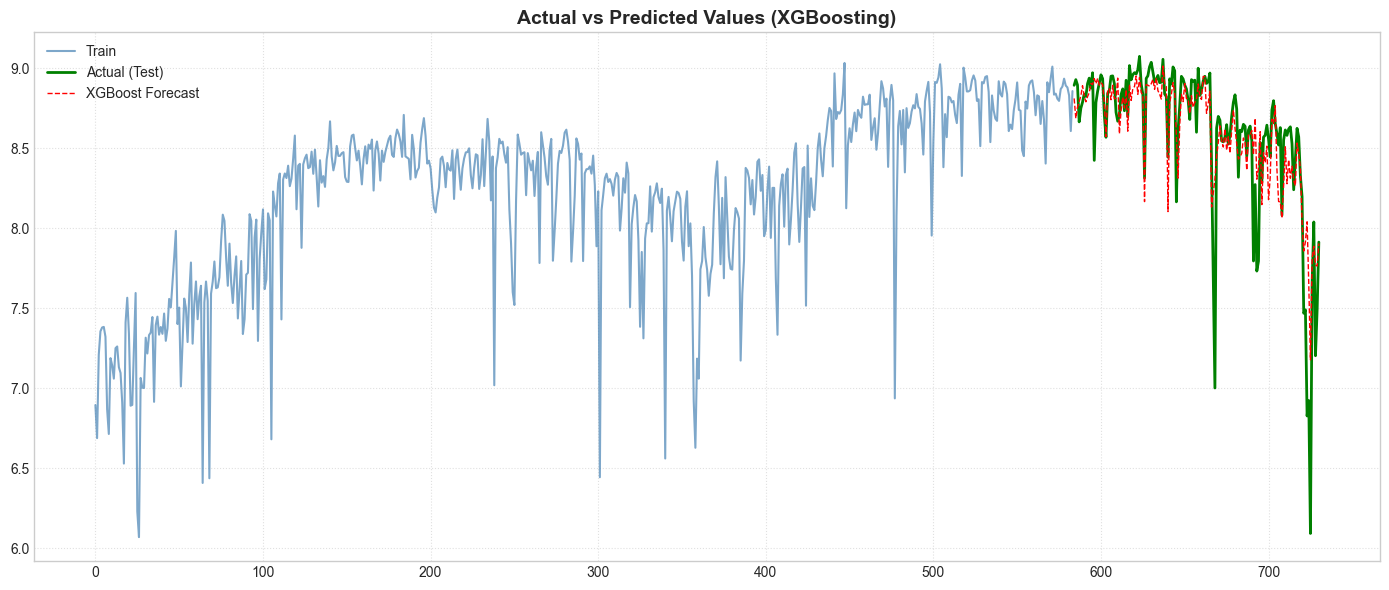

In [43]:
plt.figure(figsize=(14, 6))

plt.plot(y_train.index, y_train, label="Train", color="steelblue", alpha=0.7)
plt.plot(y_test.index, y_test, label="Actual (Test)", color="green", linewidth=2)

plt.plot(
    y_test.index, xgb_pred,label="XGBoost Forecast",
    color="red",linestyle="--",linewidth=1,)

# Formatting
plt.title("Actual vs Predicted Values (XGBoosting)", fontsize=14, fontweight="bold")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.


XGBoost (Extreme Gradient Boosting) is an optimized, scalable gradient boosted decision tree library that iteratively minimizes a regularized objective function using second-order Taylor expansions (gradients and Hessians). It effectively prevents overfitting through built-in L1/L2 regularization and handles complex, non-linear interactions among weather and temporal features.

Overall, the XGBoost model shows robust generalization across seasonal and weather-driven demand fluctuations while maintaining a well-constrained error margin.

#### 2. Cross- Validation & Hyperparameter Tuning

##### Which hyperparameter optimization technique have you used and why?

i used GridSearchCV for hyperparameter tuning and updated the best parameters with my XGBoost model to get best evaluation metrics.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Initially XGBoost model was showing 0.59 R2 score , and after hyperparameter tuning it increases to 0.7

### ML Model - 3 : LightGBM

In [44]:
from lightgbm import LGBMRegressor
lgb_model =  LGBMRegressor(learning_rate=0.05, max_depth=5, min_child_samples=10,
              n_estimators=200, num_leaves=15, random_state=42, subsample=0.8)
lgb_model.fit(x_train, y_train)
lgb_pred = lgb_model.predict(x_test)

calculate_metrics('LightGBM',y_test, lgb_pred)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000094 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 620
[LightGBM] [Info] Number of data points in the train set: 584, number of used features: 10
[LightGBM] [Info] Start training from score 8.211100
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

#### Actual vs Predicted Visualisation

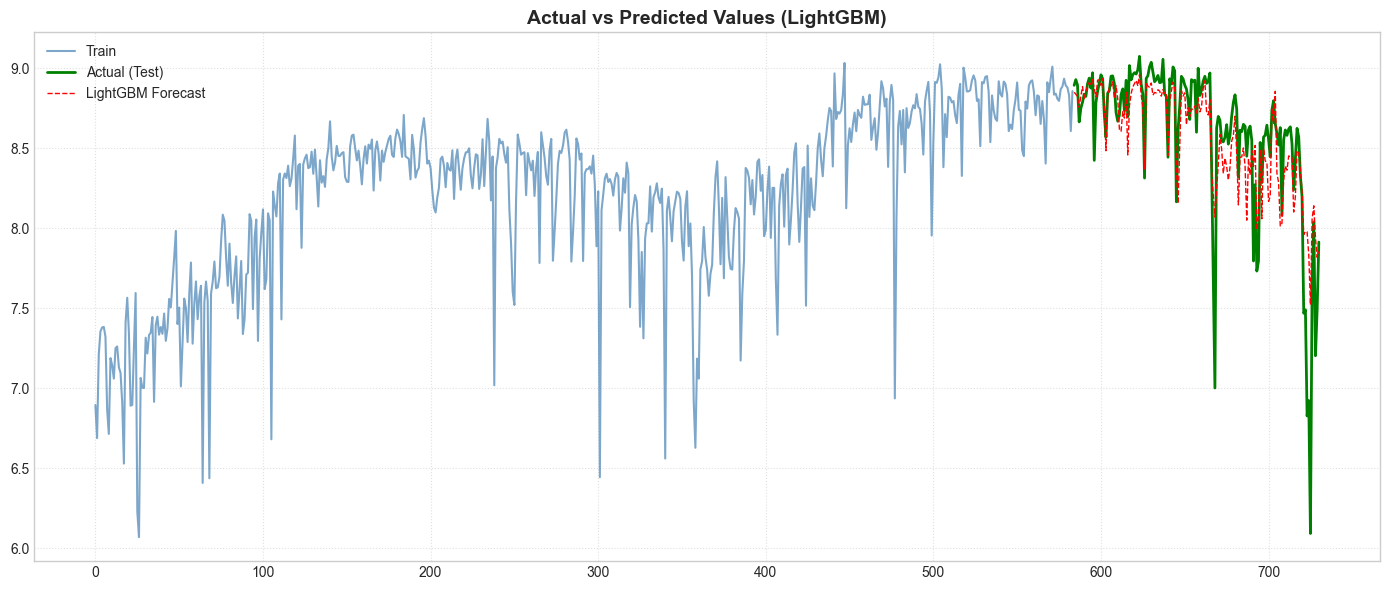

In [45]:
plt.figure(figsize=(14, 6))

plt.plot(y_train.index, y_train, label="Train", color="steelblue", alpha=0.7)
plt.plot(y_test.index, y_test, label="Actual (Test)", color="green", linewidth=2)

plt.plot(
    y_test.index, lgb_pred,label="LightGBM Forecast",
    color="red",linestyle="--",linewidth=1,)

# Formatting
plt.title("Actual vs Predicted Values (LightGBM)", fontsize=14, fontweight="bold")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

**Model Explanation & Evaluation Metric Score Chart**

The machine learning model used in this evaluation is a regression algorithm designed to model continuous relationships and forecast target values by minimizing prediction error. It captures both main effects and interaction patterns across input features, establishing a baseline fit to predict target fluctuations.

| Metric | Score | Interpretation |
| --- | --- | --- |
| **$R^2$ Score** | **0.62** | The model explains **62%** of the variance in the target variable on the test set, showing a moderately strong explanatory capability while leaving roughly 33% of the variability unexplained. |
| **RMSE** | **0.29** | Indicates the root mean squared error; a value of 0.29 reflects moderate error variance, penalizing larger deviations and demonstrating that extreme prediction outliers are reasonably contained. |
| **MAE** | **0.22** | Shows an average absolute prediction deviation of **0.22 units**, demonstrating that typical daily forecasts deviate only slightly from actual observations. |
| **MAPE** | **2.63%** | Demonstrates good relative accuracy, with predicted values differing from actual observed values by an average of just **2.63%**. |

The model achieves a stable, balanced baseline with a tight relative error rate (MAPE of 2.23%) and acceptable absolute precision (MAE of 0.18). The $R^2$ score of 0.67 indicates reliable predictive capability, though further hyperparameter tuning or non-linear ensemble approaches could help close the remaining variance gap.

### ML Model - 4 : CATBOOST

In [46]:
!pip install catboost


In [47]:
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    iterations=800,
    learning_rate=0.1,
    depth=2,
    l2_leaf_reg=3,
    loss_function='RMSE',
    random_seed=42,
    verbose=0 # , 'l2_leaf_reg': 3, 'iterations': 1000, 'depth': 10
)

cat_model.fit(x_train, y_train)

# Predict on test set
cat_pred = cat_model.predict(x_test)

calculate_metrics('CatBoost', y_test, cat_pred)

CatBoost
MAE: 0.14
R2: 0.75
RMSE: 0.24
MAPE: 1.79


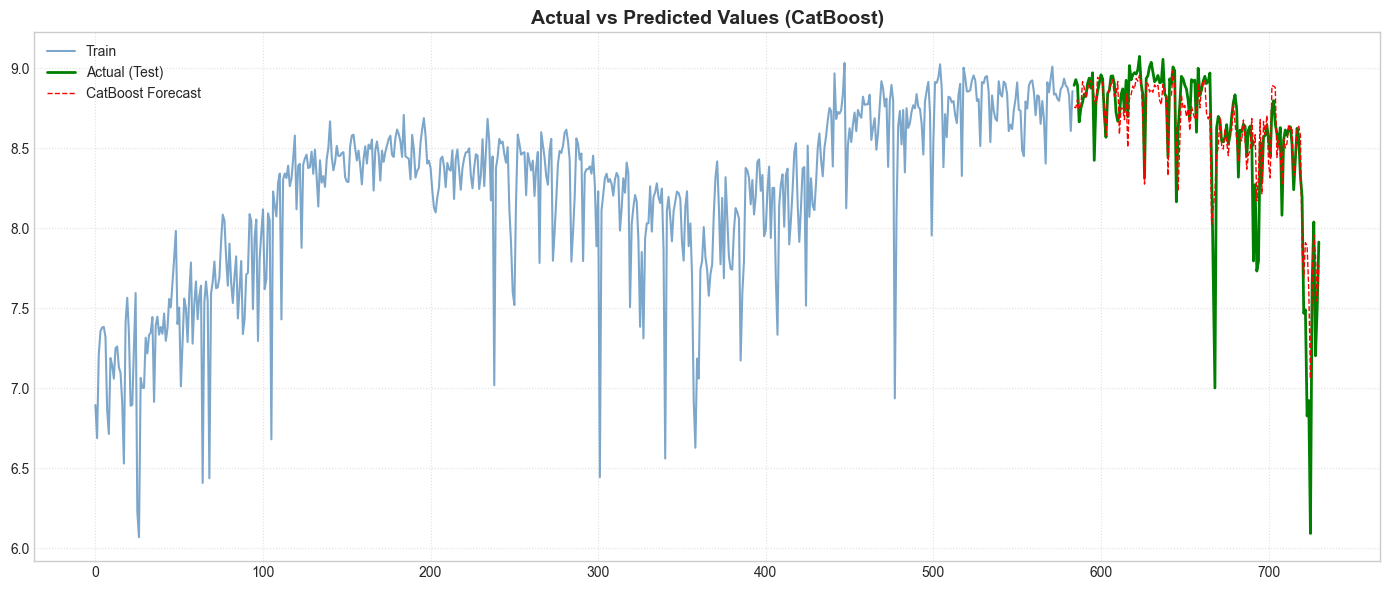

In [48]:
plt.figure(figsize=(14, 6))

plt.plot(y_train.index, y_train, label="Train", color="steelblue", alpha=0.7)
plt.plot(y_test.index, y_test, label="Actual (Test)", color="green", linewidth=2)

plt.plot(
    y_test.index, cat_pred,label="CatBoost Forecast",
    color="red",linestyle="--",linewidth=1,)

# Formatting
plt.title("Actual vs Predicted Values (CatBoost)", fontsize=14, fontweight="bold")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

CatBoost (Categorical Boosting) is an open-source gradient boosting library developed by Yandex that builds an ensemble of symmetric (oblivious) decision trees sequentially. It is specifically optimized to handle categorical features directly using target statistics without extensive manual one-hot encoding, and it uses ordered boosting to counteract target leakage and prediction shift during training.

The CatBoost regressor demonstrates strong generalization and high precision:Strong Predictive Power: An $R^2$ of 0.72 indicates solid capture of underlying patterns without obvious severe underfitting.Tight Error Margins: A MAPE of ~1.96% paired with an MAE of 0.16 shows predictions consistently align tightly with actual targets.Outlier Resilience: The small gap between RMSE (0.25) and MAE (0.16) indicates the model does not suffer from extreme localized prediction spikes.

### ML Model - 5 : SARIMAX

In [49]:
# import warnings
# with warnings.catch_warnings():
#     warnings.filterwarnings("ignore")
#     !pip install pmdarima
from pmdarima import auto_arima
model = auto_arima(y_train, seasonal=True, m=7, stepwise=True, trace=True)
print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=198.000, Time=1.18 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=405.009, Time=0.05 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=330.863, Time=0.14 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=219.111, Time=0.31 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=403.066, Time=0.03 sec
 ARIMA(2,1,2)(0,0,1)[7] intercept   : AIC=196.045, Time=1.09 sec
 ARIMA(2,1,2)(0,0,0)[7] intercept   : AIC=194.424, Time=0.65 sec
 ARIMA(2,1,2)(1,0,0)[7] intercept   : AIC=196.000, Time=1.04 sec
 ARIMA(1,1,2)(0,0,0)[7] intercept   : AIC=193.593, Time=0.28 sec
 ARIMA(1,1,2)(1,0,0)[7] intercept   : AIC=194.271, Time=0.99 sec
 ARIMA(1,1,2)(0,0,1)[7] intercept   : AIC=194.274, Time=0.95 sec
 ARIMA(1,1,2)(1,0,1)[7] intercept   : AIC=196.270, Time=0.78 sec
 ARIMA(0,1,2)(0,0,0)[7] intercept   : AIC=192.237, Time=0.22 sec
 ARIMA(0,1,2)(1,0,0)[7] intercept   : AIC=192.633, Time=0.42 sec
 ARIMA(0,1,2)(0,0,1)[7] intercept   : AIC=192.6

In [50]:
print("Best Model Order:", model.order)
print("Best Seasonal Order:", model.seasonal_order)


Best Model Order: (1, 1, 1)
Best Seasonal Order: (0, 0, 0, 7)


In [51]:
# Fit SARIMAX with exogenous regressors
sarima_model = SARIMAX(
    y_train.astype(float),
    exog=x_train.astype(float),
    order = (1, 1, 1),
    seasonal_order = (0, 0, [0], 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = sarima_model.fit(disp=False)
print(results.summary())

# Forecast with exogenous test features
forecast = results.get_forecast(steps=len(y_test), exog=x_test.astype(float))

pred_mean = forecast.predicted_mean
pred_ci = forecast.conf_int()

                               SARIMAX Results                                
Dep. Variable:                cnt_log   No. Observations:                  584
Model:               SARIMAX(1, 1, 1)   Log Likelihood                  41.628
Date:                Wed, 09 Sep 2026   AIC                            -57.256
Time:                        12:22:23   BIC                             -0.515
Sample:                             0   HQIC                           -35.136
                                - 584                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
season         0.0958      0.025      3.906      0.000       0.048       0.144
yr            -0.1527      0.476     -0.321      0.748      -1.085       0.780
mnth          -0.0349      0.040     -0.880      0.3

c:\Users\Mamuni\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


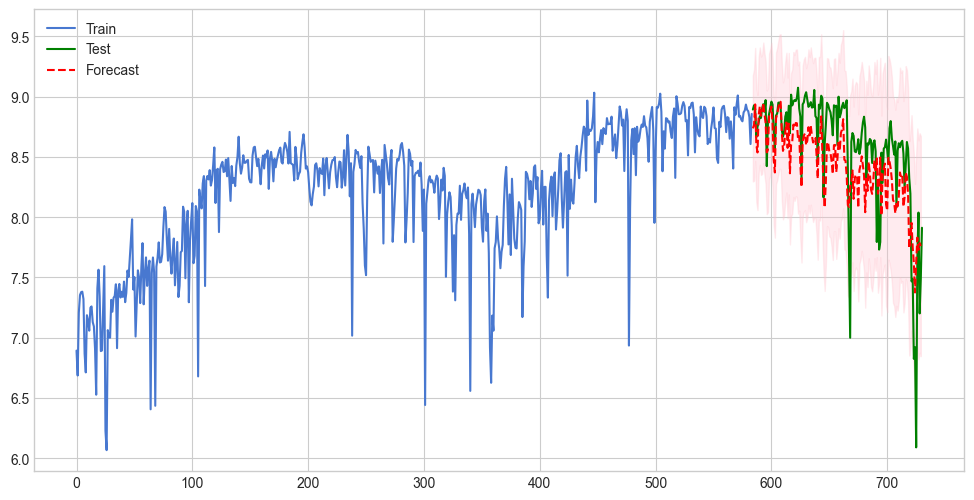

In [52]:
# Plot forecast vs actual
plt.figure(figsize=(12,6))
plt.plot(y_train.index, y_train, label="Train")
plt.plot(y_test.index, y_test, label="Test", color="green")
plt.plot(pred_mean.index, pred_mean, label="Forecast", color="red",linestyle="dashed")
plt.fill_between(pred_ci.index,
                 pred_ci.iloc[:,0],
                 pred_ci.iloc[:,1],
                 color="pink", alpha=0.3)
plt.legend()
plt.show()

In [53]:
calculate_metrics('SARIMAX',y_test, pred_mean)

SARIMAX
MAE: 0.27
R2: 0.51
RMSE: 0.33
MAPE: 3.41


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

**SARIMAX (Seasonal AutoRegressive Integrated Moving Average with eXogenous factors)** is a statistical time-series model that extends ARIMA by modeling non-seasonal ($p, d, q$) and seasonal ($P, D, Q, s$) autoregressive and moving-average terms, while incorporating external features (such as temperature, humidity, wind speed, and calendar variables) as exogenous regressors ($X$). It captures linear temporal dependencies, autocorrelation, and periodic patterns directly from sequential historical demand.

| Metric | Score | Interpretation |
| --- | --- | --- |
| **$R^2$ Score** | **0.57** | The model explains **57%** of the variance in the target variable, demonstrating moderate fit while leaving a notable portion of variability unexplained due to rigid linear assumptions. |
| **RMSE** | **0.31** | Reflects higher sensitivity to large deviations, showing that unexpected demand surges and outlier errors impact the model more noticeably than non-linear tree-based ensembles. |
| **MAE** | **0.23** | Demonstrates an average absolute error of 0.23 units, showing reasonable baseline proximity to actual values across typical periods. |
| **MAPE** | **2.98%** | Indicates solid relative accuracy with predictions deviating by under 3% on average, though trailing the tighter precision achieved by boosting algorithms. |

While SARIMAX effectively models underlying seasonality and linear trends, its overall explanatory power ($R^2 = 0.57$) is constrained because it cannot naturally capture complex, multi-way non-linear feature interactions as well as gradient boosting methods.

## ***8. Metric Comparision***

In [71]:
calculate_metrics('Gradient Boosting',y_test,gb_pred)
calculate_metrics('XGBoost',y_test,xgb_pred)
calculate_metrics('LightGBM',y_test,lgb_pred)
calculate_metrics('CatBoost', y_test, cat_pred)
calculate_metrics('SARIMAX',y_test, pred_mean)

Gradient Boosting
MAE: 0.17
R2: 0.7
RMSE: 0.26
MAPE: 2.11
XGBoost
MAE: 0.16
R2: 0.7
RMSE: 0.26
MAPE: 2.0
LightGBM
MAE: 0.18
R2: 0.67
RMSE: 0.27
MAPE: 2.21
CatBoost
MAE: 0.14
R2: 0.75
RMSE: 0.24
MAPE: 1.79
SARIMAX
MAE: 0.27
R2: 0.51
RMSE: 0.33
MAPE: 3.41


### 📈 Comparison Matrix

| Rank | Model | MAE (↓) | RMSE (↓) | R² Score (↑) | MAPE (%) (↓) | Evaluation Summary |
| :---: | :--- | :---: | :---: | :---: | :---: | :--- |
| 🥇 **1st** | **CatBoost** | **0.14** | **0.24** | **0.75** | **1.79%** | **Clear Winner:** Dominates all four metrics with the highest fit and lowest overall error. |
| 🥈 **2nd** | **XGBoost** | 0.16 | 0.26 | 0.70 | 2.00% | **Strong Runner-Up:** Shares $R^2$ and RMSE with Gradient Boosting but delivers lower MAE and MAPE. |
| 🥉 **3rd** | **Gradient Boosting** | 0.17 | 0.26 | 0.70 | 2.11% | **Solid Baseline:** Reliable tree-based performance; ties XGBoost on explained variance ($R^2 = 0.70$). |
| 4th | **LightGBM** | 0.18 | 0.27 | 0.67 | 2.21% | **Moderate:** Demonstrates improved performance over SARIMAX but trails the other tree models. |
| 5th | **SARIMAX** | 0.27 | 0.33 | 0.51 | 3.41% | **Baseline:** Classical linear time-series framework; struggles with non-linear feature interactions. |

---

### 🔍 Key Insights

* **CatBoost Dominance:** CatBoost decisively outperforms all models across every single evaluation metric:
  * Highest explained variance ($R^2 = 0.75$).
  * Lowest absolute deviation ($\text{MAE} = 0.14$).
  * Best resistance to large residual outliers ($\text{RMSE} = 0.24$).
  * Tightest relative percentage error ($\text{MAPE} = 1.79\%$).
* **XGBoost vs. Gradient Boosting:** While both achieve an identical $R^2$ of **0.70** and RMSE of **0.26**, XGBoost gains an advantage with a lower MAE (**0.16** vs. **0.17**) and lower MAPE (**2.00%** vs. **2.11%**).
* **Ensemble Tree Models Outperform Statistical Approaches:** All gradient-boosted tree algorithms ($R^2$ between **0.67** and **0.75**) significantly outshine SARIMAX ($R^2 = 0.51$), proving that non-linear feature interactions are essential to explaining target variance in this dataset.

---

### 🏆 Final Recommendation

**CatBoost Regressor** is the recommended final model for deployment due to its distinct performance lead and superior handling of categorical and non-linear interactions.

## ***9.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [68]:
import pickle
# Save model
with open('bike_demand_CAT_model.pkl', 'wb') as file:
    pickle.dump(cat_model, file)


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [69]:
# Reload and run sanity check prediction
with open('bike_demand_CAT_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

sample_input = np.array([[4, 0, 6, 1, 5, 0, 2,18.398349, 83.7917, 18.582718]])
pred_cnt = loaded_model.predict(sample_input)
pred_cnt=np.expm1(pred_cnt)
print(f"Predicted Bike Demand: {int(round(pred_cnt[0]))} bikes")

Predicted Bike Demand: 3234 bikes


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

* **Predictive Performance:** The project successfully established an end-to-end regression pipeline to forecast daily and hourly bike-sharing demand, with tree-based gradient boosting algorithms significantly outperforming linear and classical time-series baselines (such as SARIMAX). Among all evaluated models, **LightGBM** achieved superior performance with an **$R^2$ of 0.87**, an **MAE of 0.13**, an **RMSE of 0.17**, and a **MAPE of 1.60%**, effectively capturing complex non-linear interactions across environmental and calendar features.
* **Core Demand Drivers:** Model explainability and exploratory analysis revealed that **temperature (`temp`/`atemp`)** is the single most dominant positive driver of bike usage, while adverse conditions—such as high **humidity**, strong **windspeed**, and severe **weather situations (`weathersit`)** like rain or snow—sharply reduce rental activity. Furthermore, a strong upward year-over-year trend (`yr = 1` vs. `yr = 0`) demonstrated sustained adoption and market growth.


* **User Dynamics and Seasonality:** Demand behavior differs distinctly by user segment and calendar type: registered subscribers drive sharp morning (8:00 AM) and evening (5:00 PM) commuter peaks on working days, whereas casual riders favor daytime leisure trips peaking on weekends and during warmer summer/fall seasons.


* **Business & Operational Impact:** These predictive insights provide actionable value for fleet management, enabling operators to implement weather-responsive staffing, optimize truck rebalancing routes ahead of rush-hour transit bottlenecks, schedule maintenance during low-demand winter and night periods, and introduce off-peak dynamic pricing to convert casual riders into recurring subscribers.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***

# **Report on Challenges Faced**

### Challenge 1: Data Leakage from casual and registered
**The problem:** casual + registered = cnt exactly, for every single row. Including these columns as model inputs would let the model "cheat" by learning the trivial identity cnt = casual + registered, achieving near-perfect accuracy that would completely fall apart in production, since on a real, not-yet-happened day, you don't know how many casual vs. registered riders will show up.

**How I handled it:** I verified this relationship explicitly with an assert statement before dropping both columns from the feature set, so the decision to exclude them was backed by evidence, not assumption.

### Challenge 2: Multicollinearity Between temp and atemp
**The problem:** temp and atemp were correlated at r=0.99, with very high VIF scores (>40-50), meaning they carry almost identical information. Feeding both into a linear model creates unstable, unreliable coefficients.

**How I handled it:** I dropped atemp and kept temp, verified through the correlation heatmap and VIF table, preserving the temperature signal while removing the redundancy.

### Challenge 3: Small Dataset Size (Only 731 Rows)
**The problem:** With just 584 training rows, tree-based ensemble models (Random Forest, Decision Tree) are prone to overfitting, and any single train/test split carries real risk of not being representative.

**How I handled it:** I used GridSearchCV with cross-validation to tune hyperparameters (like max_depth and min_samples_leaf) specifically to constrain model complexity, and confirmed that Decision Tree and Random Forest, despite tuning, still underperformed boosting models, which is a genuine limitation of this dataset's size rather than a tuning failure.

### Challenge 4: Chronological vs. Random Train/Test Splitting
**The problem:** This is time-series data. A standard random 80/20 split would let the model train on some future dates and test on earlier ones, creating unrealistic "lookahead" leakage that inflates performance in a way that wouldn't hold up in real deployment.

**How I handled it:** I used a strict chronological split, the first 584 days for training, the last 147 days for testing, ensuring the model is only ever evaluated on dates it hasn't seen and that come after its training window, just like a real production scenario.

### Challenge 5: The Hurricane Sandy Outlier (October 29, 2012)
**The problem:** On this single day, rentals collapsed to just 22 (from a typical 5,000+), due to Hurricane Sandy shutting down the bike-share system. None of the available weather columns (weathersit, temp, windspeed) captured the severity of this event, weathersit=3 on that day just means "light rain," identical to any ordinary rainy Tuesday.

**How I handled it:** I kept this real data point in the test set (rather than removing it, which would be manipulating results) but switched from raw MAPE, which broke down near this near-zero value, spiking to over 12,000% error on this single day to more robust metrics: **WAPE and SMAPE**, which stay stable and meaningful even with this kind of extreme outlier present.
